# Customer Segmentation using K-Means (Mall Customers)

Goal: Segment customers into meaningful groups using **K-Means clustering** and interpret each segment for business actions.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Shape:", df.shape)
display(df.info())
display(df.isnull().sum())

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [5]:
df.describe(include="all")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [6]:
df = df.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
})
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


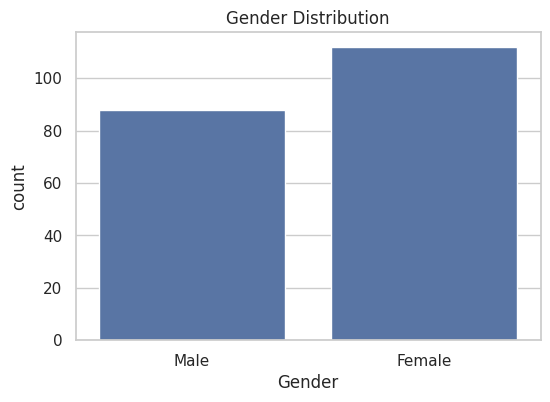

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

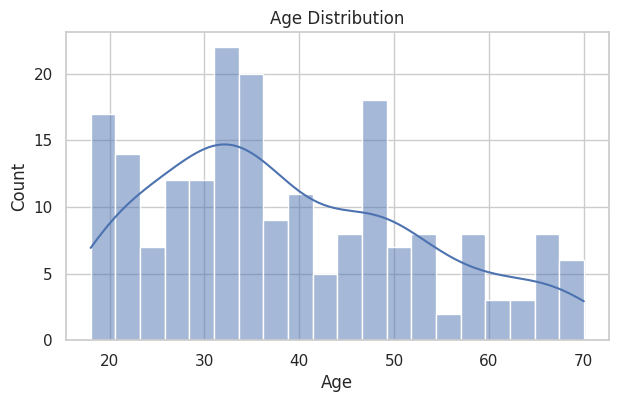

In [8]:
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

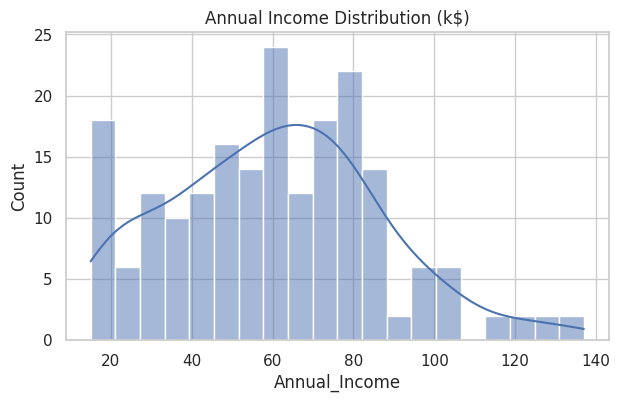

In [10]:
plt.figure(figsize=(7,4))
sns.histplot(df["Annual_Income"], bins=20, kde=True)
plt.title("Annual Income Distribution (k$)")
plt.show()

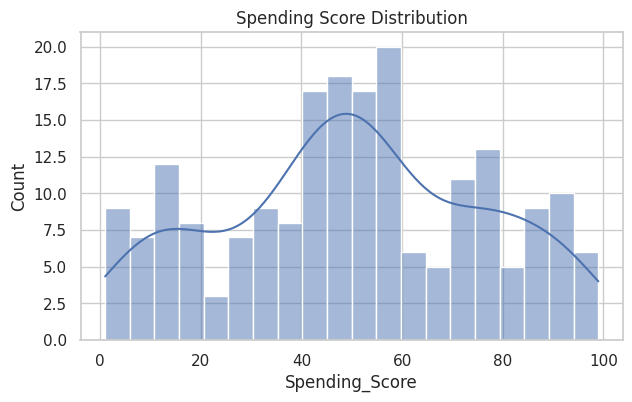

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(df["Spending_Score"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

In [12]:
features = ["Annual_Income", "Spending_Score"]
X = df[features].copy()
X.head()

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

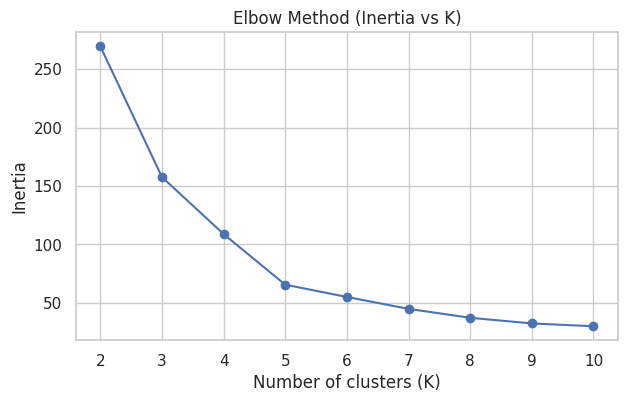

In [14]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

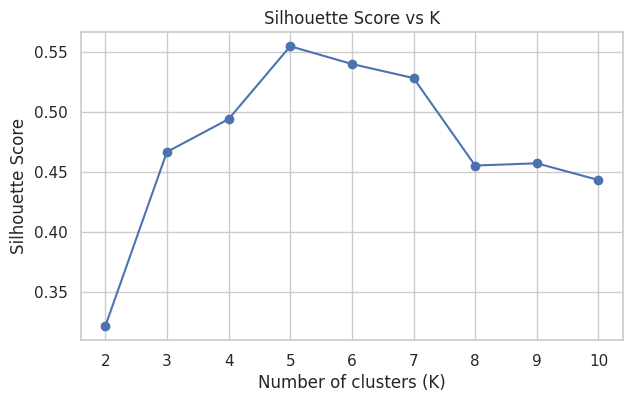

Best K by silhouette: 5


In [15]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Best K by silhouette:", best_k)

In [16]:
k = best_k  # or set manually like k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df[["Gender", "Age", "Annual_Income", "Spending_Score", "Cluster"]].head()

,Gender,Age,Annual_Income,Spending_Score,Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


In [17]:
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=features)
centers_df["Cluster"] = range(k)
centers_df

,Annual_Income,Spending_Score,Cluster
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,25.727273,79.363636,2
3,88.200000,17.114286,3
4,26.304348,20.913043,4


In [18]:
profile = df.groupby("Cluster")[["Age", "Annual_Income", "Spending_Score"]].agg(["count", "mean", "median"]).round(2)
profile

Age               Annual_Income               Spending_Score         \
        count   mean median         count   mean median          count   mean   
Cluster                                                                         
0          81  42.72   46.0            81  55.30   54.0             81  49.52   
1          39  32.69   32.0            39  86.54   79.0             39  82.13   
2          22  25.27   23.5            22  25.73   24.5             22  79.36   
3          35  41.11   42.0            35  88.20   85.0             35  17.11   
4          23  45.22   46.0            23  26.30   25.0             23  20.91   

                
        median  
Cluster         
0         50.0  
1         83.0  
2         77.0  
3         16.0  
4         17.0

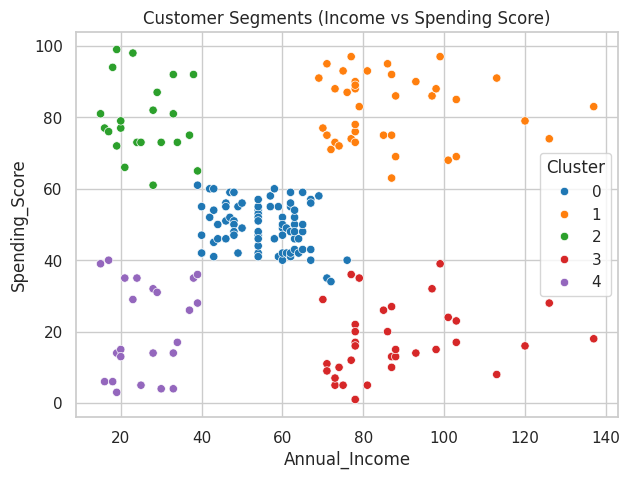

In [19]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="Annual_Income", y="Spending_Score",
    hue="Cluster", data=df, palette="tab10"
)
plt.title("Customer Segments (Income vs Spending Score)")
plt.show()

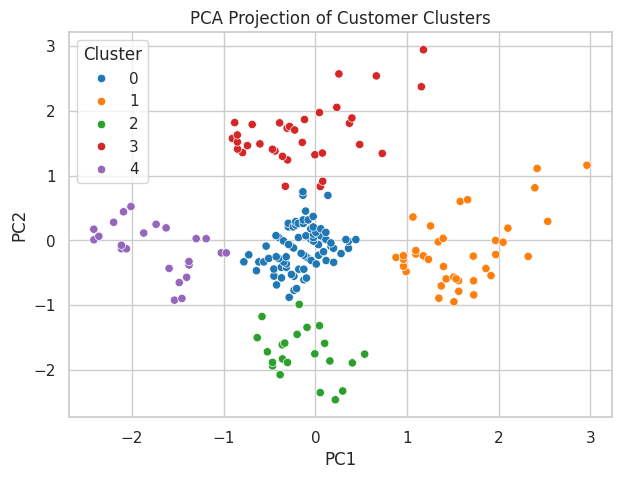

Explained variance ratio: [0.50495142 0.49504858]


In [20]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"]

plt.figure(figsize=(7,5))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=pca_df, palette="tab10")
plt.title("PCA Projection of Customer Clusters")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## Segment Interpretation (Example)

Use the profile table and cluster centers to label segments, e.g.:

- **Cluster A:** High income + high spending → premium customers
- **Cluster B:** High income + low spending → upsell opportunity
- **Cluster C:** Low income + high spending → deal-driven / impulsive buyers
- **Cluster D:** Low income + low spending → low engagement

In [22]:
df.to_csv("segmented_customers.csv", index=False)
print("Saved: segmented_customers.csv")

Saved: segmented_customers.csv


In [23]:
import os
os.makedirs("assets", exist_ok=True)

# Income vs Spending
plt.figure(figsize=(7,5))
sns.scatterplot(x="Annual_Income", y="Spending_Score", hue="Cluster", data=df, palette="tab10")
plt.title("Customer Segments (Income vs Spending Score)")
plt.savefig("assets/customer_segments_income_spending.png", bbox_inches="tight", dpi=200)
plt.close()

# Elbow
plt.figure(figsize=(7,4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.savefig("assets/elbow_curve.png", bbox_inches="tight", dpi=200)
plt.close()

# Silhouette
plt.figure(figsize=(7,4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.savefig("assets/silhouette_vs_k.png", bbox_inches="tight", dpi=200)
plt.close()

# PCA
plt.figure(figsize=(7,5))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=pca_df, palette="tab10")
plt.title("PCA Projection of Customer Clusters")
plt.savefig("assets/pca_clusters.png", bbox_inches="tight", dpi=200)
plt.close()

print("Saved plots to assets/")

Saved plots to assets/
